# Projet IA

## Chargement Individuel des Datasets

### Importation des bibliothèques

In [189]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier


In [190]:
def build_time_features(df_in, df_out):
    in_datetimes = df_in.apply(pd.to_datetime, errors="coerce")
    out_datetimes = df_out.apply(pd.to_datetime, errors="coerce")

    in_minutes = in_datetimes.apply(
        lambda column: column.dt.hour * 60 + column.dt.minute + column.dt.second / 60
    )
    out_minutes = out_datetimes.apply(
        lambda column: column.dt.hour * 60 + column.dt.minute + column.dt.second / 60
    )
    work_duration_hours = (out_minutes - in_minutes) / 60

    return pd.DataFrame(
        {
            "InTimeAvgMinutes": in_minutes.mean(axis=1),
            "InTimeStdMinutes": in_minutes.std(axis=1),
            "InTimeMissingDays": in_minutes.isna().sum(axis=1),
            "OutTimeAvgMinutes": out_minutes.mean(axis=1),
            "OutTimeStdMinutes": out_minutes.std(axis=1),
            "OutTimeMissingDays": out_minutes.isna().sum(axis=1),
            "AvgWorkDurationHours": work_duration_hours.mean(axis=1),
            "StdWorkDurationHours": work_duration_hours.std(axis=1),
            "MissingWorkDurationDays": work_duration_hours.isna().sum(axis=1),
        }
    )

df_employee = pd.read_csv(
    "./Data/employee_survey_data.csv",
    sep=",",
    header=0,
    names=["EmployeeID","EnvironmentSatisfaction","JobSatisfaction","WorkLifeBalance"]
)
df_general = pd.read_csv(
    "./Data/general_data.csv",
    sep=",",
    header=0,
    names=["Age","Attrition","BusinessTravel","Department","DistanceFromHome","Education","EducationField","EmployeeCount","EmployeeID","Gender","JobLevel","JobRole","MaritalStatus","MonthlyIncome","NumCompaniesWorked","Over18","PercentSalaryHike","StandardHours","StockOptionLevel","TotalWorkingYears","TrainingTimesLastYear","YearsAtCompany","YearsSinceLastPromotion","YearsWithCurrManager"]
)
df_manager = pd.read_csv(
    "./Data/manager_survey_data.csv",
    sep=",",
    header=0,
    names=["EmployeeID","JobInvolvement","PerformanceRating"]
)
df_in = pd.read_csv("./Data/in_out_time/in_time.csv", sep=",", header=0, index_col=0)
df_out = pd.read_csv("./Data/in_out_time/out_time.csv", sep=",", header=0, index_col=0)
df_in.index.name = "EmployeeID"
df_out.index.name = "EmployeeID"
df_time_features = build_time_features(df_in, df_out)

# Imputer les valeurs manquantes pour chaque dataset
for df in [df_employee, df_general, df_manager, df_time_features]:
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
    cat_cols = df.select_dtypes(include=['object']).columns
    if len(cat_cols) > 0:
        df[cat_cols] = df[cat_cols].fillna("Unknown")

/tmp/ipykernel_342753/3271685107.py:56: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


## Fusion des datasets en un dataframe unique

In [191]:
# Fusionner les quatre sources en utilisant EmployeeID comme clé
# Tous les datasets partagent la même population d'employés, donc une fusion interne ne garde que les employés correspondants.
df_merged = (
    df_general
    .merge(df_employee, on='EmployeeID', how='inner')
    .merge(df_manager, on='EmployeeID', how='inner')
    .merge(df_time_features.reset_index(), on='EmployeeID', how='inner')
)
print('Taille du dataframe fusionné :', df_merged.shape)
print('Nombre d\'EmployeeID uniques :', df_merged['EmployeeID'].nunique())
print('Lignes avec EmployeeID en double :', df_merged.duplicated(subset=['EmployeeID']).sum())
print('\nColonnes du dataframe fusionné :')
print(df_merged.columns.tolist())

# Utiliser le dataframe fusionné pour le prétraitement et l'analyse ultérieurs
# Cela garde le dataset unifié et préserve les données d'enquête des employés, des managers et du temps.
df_general = df_merged.copy()

Taille du dataframe fusionné : (4410, 38)
Nombre d'EmployeeID uniques : 4410
Lignes avec EmployeeID en double : 0

Colonnes du dataframe fusionné :
['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeID', 'Gender', 'JobLevel', 'JobRole', 'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked', 'Over18', 'PercentSalaryHike', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'PerformanceRating', 'InTimeAvgMinutes', 'InTimeStdMinutes', 'InTimeMissingDays', 'OutTimeAvgMinutes', 'OutTimeStdMinutes', 'OutTimeMissingDays', 'AvgWorkDurationHours', 'StdWorkDurationHours', 'MissingWorkDurationDays']


### Informations sur le dataset fusionné

In [192]:
print("-------------------- Dataset Fusionné --------------------")
print("-------------------- HEAD --------------------")
print(df_general.head())
print("-------------------- DESCRIBE --------------------")
print(df_general.describe())
print("-------------------- INFO --------------------")
print(df_general.info())
print("-------------------- Valeurs Manquantes --------------------")
print(df_general.isnull().sum())
print("-------------------- Valeurs en Double --------------------")
print(df_general.duplicated().sum())
print("---------------------------------------------------")

-------------------- Dataset Fusionné --------------------
-------------------- HEAD --------------------
   Age Attrition     BusinessTravel              Department  DistanceFromHome  \
0   51        No      Travel_Rarely                   Sales                 6   
1   31       Yes  Travel_Frequently  Research & Development                10   
2   32        No  Travel_Frequently  Research & Development                17   
3   38        No         Non-Travel  Research & Development                 2   
4   32        No      Travel_Rarely  Research & Development                10   

   Education EducationField  EmployeeCount  EmployeeID  Gender  ...  \
0          2  Life Sciences              1           1  Female  ...   
1          1  Life Sciences              1           2  Female  ...   
2          4          Other              1           3    Male  ...   
3          5  Life Sciences              1           4    Male  ...   
4          1        Medical              1          

In [193]:
print("-------------------- Dataset original des Employés --------------------")
print("-------------------- HEAD --------------------")
print(df_employee.head())
print("-------------------- DESCRIBE --------------------")
print(df_employee.describe())
print("-------------------- INFO --------------------")
print(df_employee.info())
print("-------------------- Valeurs Manquantes --------------------")
print(df_employee.isnull().sum())
print("-------------------- Valeurs en Double --------------------")
print(df_employee.duplicated().sum())
print("---------------------------------------------------")

-------------------- Dataset original des Employés --------------------
-------------------- HEAD --------------------
   EmployeeID  EnvironmentSatisfaction  JobSatisfaction  WorkLifeBalance
0           1                      3.0              4.0              2.0
1           2                      3.0              2.0              4.0
2           3                      2.0              2.0              1.0
3           4                      4.0              4.0              3.0
4           5                      4.0              1.0              3.0
-------------------- DESCRIBE --------------------
        EmployeeID  EnvironmentSatisfaction  JobSatisfaction  WorkLifeBalance
count  4410.000000              4410.000000      4410.000000      4410.000000
mean   2205.500000                 2.725170         2.729478         2.763492
std    1273.201673                 1.089852         1.098904         0.703541
min       1.000000                 1.000000         1.000000         1.000000
25

In [194]:
print("-------------------- Managers --------------------")
print("-------------------- HEAD --------------------")
print(df_manager.head())
print("-------------------- DESCRIBE --------------------")
print(df_manager.describe())
print("-------------------- INFO --------------------")
print(df_manager.info())
print("-------------------- Valeurs Manquantes --------------------")
print(df_manager.isnull().sum())
print("-------------------- Valeurs en Double --------------------")
print(df_manager.duplicated().sum())
print("---------------------------------------------------")

-------------------- Managers --------------------
-------------------- HEAD --------------------
   EmployeeID  JobInvolvement  PerformanceRating
0           1               3                  3
1           2               2                  4
2           3               3                  3
3           4               2                  3
4           5               3                  3
-------------------- DESCRIBE --------------------
        EmployeeID  JobInvolvement  PerformanceRating
count  4410.000000     4410.000000        4410.000000
mean   2205.500000        2.729932           3.153741
std    1273.201673        0.711400           0.360742
min       1.000000        1.000000           3.000000
25%    1103.250000        2.000000           3.000000
50%    2205.500000        3.000000           3.000000
75%    3307.750000        3.000000           3.000000
max    4410.000000        4.000000           4.000000
-------------------- INFO --------------------
<class 'pandas.DataFrame

Comme nous pouvons le voir, les trois dataframes sont à peu près propres mais nous devons prétraiter df_general car il contient des données textuelles.

## Prétraitement du dataset Général

#### Suppression des colonnes non-RGPD

In [195]:
# Supprimer les colonnes Gender et EmployeeID
drop_columns = [col for col in ['Gender', 'EmployeeID', 'Over18', "EmployeeCount", "StandardHours"] if col in df_general.columns]
if drop_columns:
    df_general = df_general.drop(columns=drop_columns)
    print(f'Colonnes supprimées de df_general : {drop_columns}')
else:
    print('Colonnes déjà supprimées ou absentes')

# Supprimer uniquement les lignes strictement dupliquées,
# afin de ne pas perdre des employés qui partagent un profil RH identique mais sont bien distincts.
print(f"Lignes avant nettoyage: {df_general.shape[0]}")
original_count = df_general.shape[0]
df_general = df_general.drop_duplicates(keep='first').reset_index(drop=True)
print(f"Lignes après suppression des doublons exacts: {df_general.shape[0]}")
print(f"Doublons exacts supprimés: {original_count - df_general.shape[0]}")

Colonnes supprimées de df_general : ['Gender', 'EmployeeID', 'Over18', 'EmployeeCount', 'StandardHours']
Lignes avant nettoyage: 4410
Lignes après suppression des doublons exacts: 4410
Doublons exacts supprimés: 0


## Encodage des variables catégorielles

In [196]:
features_to_encode = ['BusinessTravel','Department',
                      'EducationField','JobRole', 'MaritalStatus'
]
encoded = pd.get_dummies(df_general[features_to_encode], drop_first=True)
print(encoded)

      BusinessTravel_Travel_Frequently  BusinessTravel_Travel_Rarely  \
0                                False                          True   
1                                 True                         False   
2                                 True                         False   
3                                False                         False   
4                                False                          True   
...                                ...                           ...   
4405                             False                          True   
4406                             False                          True   
4407                             False                          True   
4408                             False                          True   
4409                             False                          True   

      Department_Research & Development  Department_Sales  \
0                                 False              True   
1            

# Création de variables numériques

In [197]:
# Ingénierie des Caractéristiques
df_general['PromotionRatio'] = df_general['YearsSinceLastPromotion'] / (df_general['YearsAtCompany'] + 1)
df_general['IncomePerYearAge'] = df_general['MonthlyIncome'] / df_general['Age']
df_general['TenurePerJob'] = df_general['TotalWorkingYears'] / (df_general['NumCompaniesWorked'] + 1)

numeric_features = [
    "Age",
    "DistanceFromHome", 
    "Education", 
    "JobLevel", 
    "MonthlyIncome",
    "NumCompaniesWorked", 
    "PercentSalaryHike", 
    "StockOptionLevel",
    "TotalWorkingYears", 
    "TrainingTimesLastYear", 
    "YearsAtCompany",
    "YearsSinceLastPromotion", 
    "YearsWithCurrManager",
    # Caractéristiques d'enquête (manquantes)
    "EnvironmentSatisfaction", 
    "JobSatisfaction", 
    "WorkLifeBalance",
    "JobInvolvement", 
    "PerformanceRating",
    # Caractéristiques de temps
    "InTimeAvgMinutes", 
    "InTimeStdMinutes", 
    "InTimeMissingDays",
    "OutTimeAvgMinutes", 
    "OutTimeStdMinutes", 
    "OutTimeMissingDays",
    "AvgWorkDurationHours", 
    "StdWorkDurationHours", 
    "MissingWorkDurationDays",
    # Ingénierie
    "PromotionRatio", "IncomePerYearAge", "TenurePerJob",
]
numeric_features = [col for col in numeric_features if col in df_general.columns]

In [198]:
# Convertir Attrition en binaire: Oui -> 1, Non -> 0
df_general['Attrition_num'] = df_general['Attrition'].map({'Yes': 1, 'No': 0})

# Définir votre cible
multi_y = df_general['Attrition_num']

### Matrice de corrélation

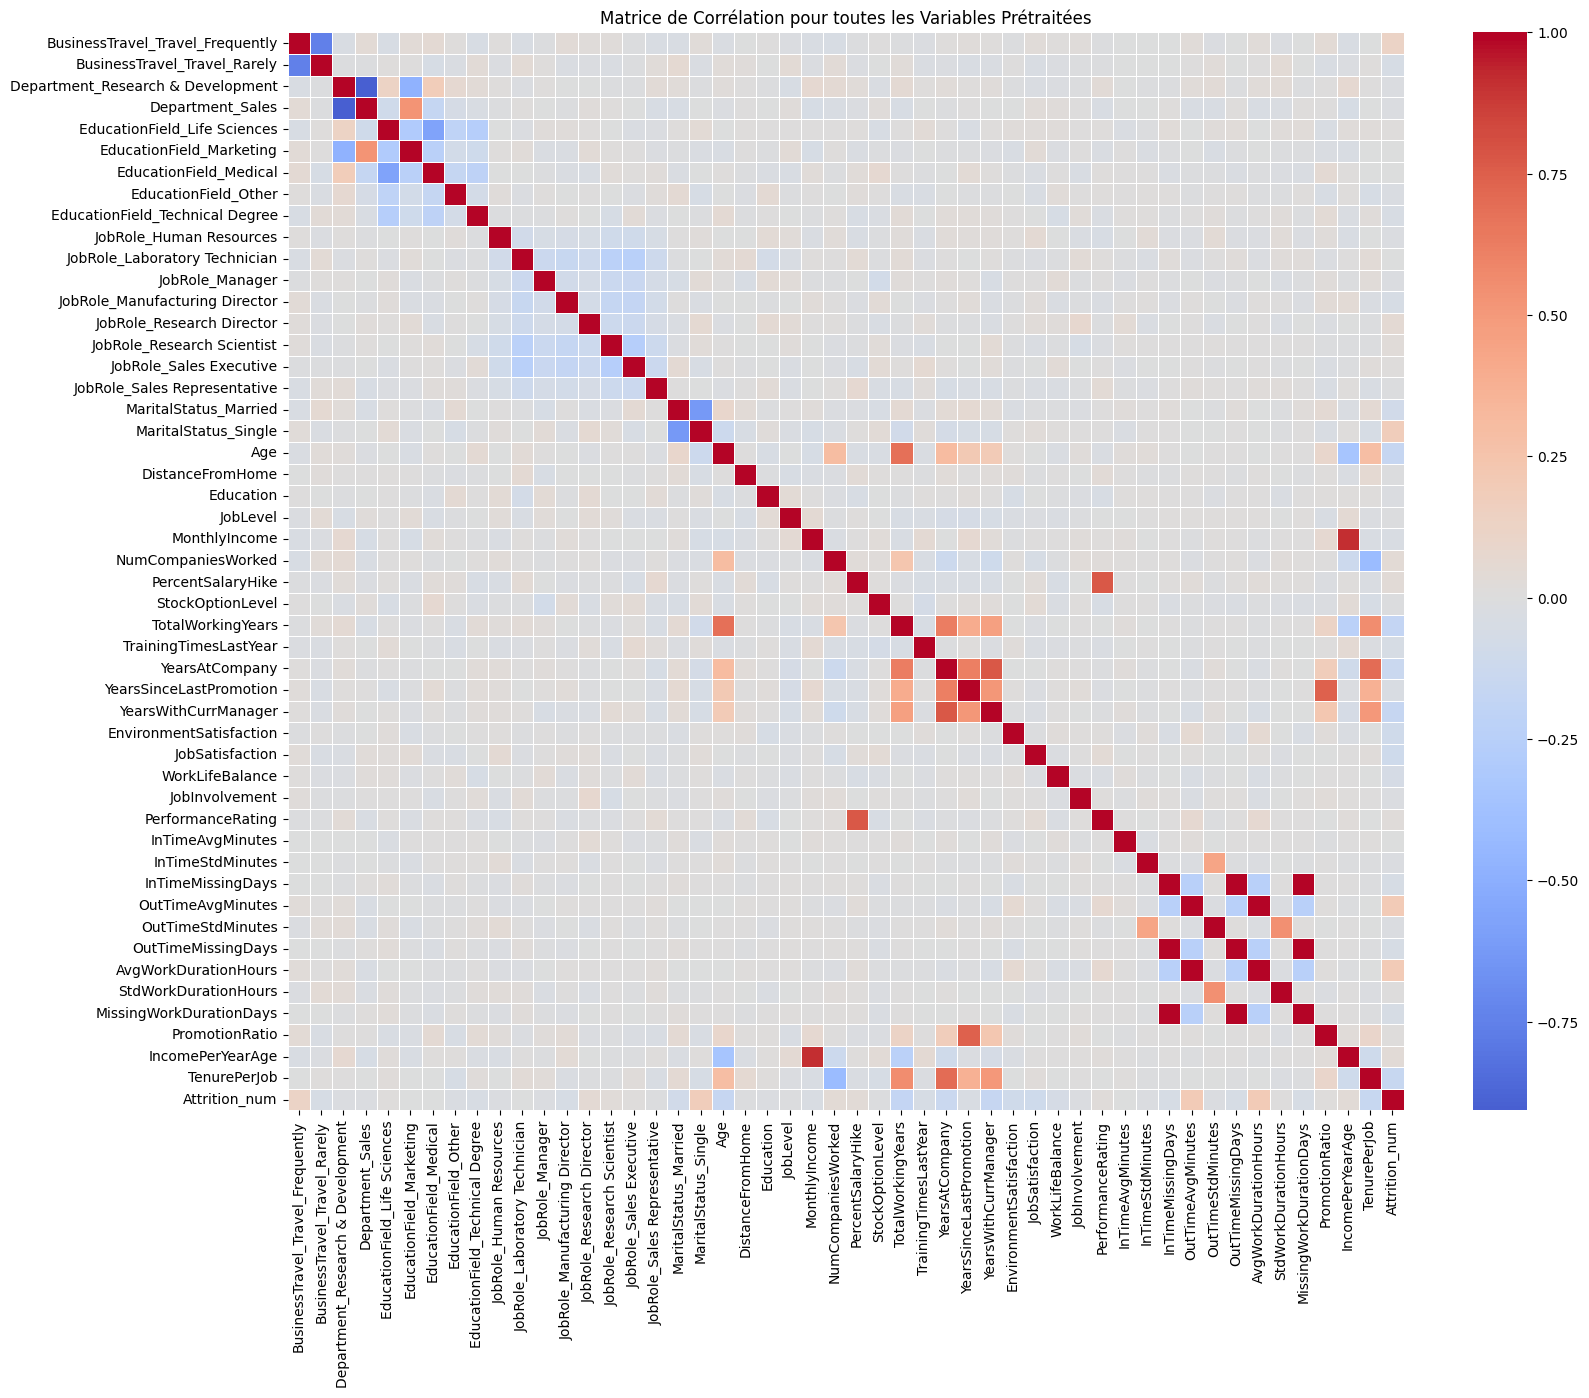

Plus fortes corrélations avec l'Attrition après prétraitement :
AvgWorkDurationHours                0.201688
OutTimeAvgMinutes                   0.201615
MaritalStatus_Single                0.175419
TotalWorkingYears                   0.170162
Age                                 0.159205
YearsWithCurrManager                0.156199
TenurePerJob                        0.149043
YearsAtCompany                      0.134392
BusinessTravel_Travel_Frequently    0.115143
JobSatisfaction                     0.103068
Name: Attrition_num, dtype: float64


In [199]:
# Calculer la matrice de corrélation avec les caractéristiques encodées et les caractéristiques numériques entières
corr_data = pd.concat([encoded, df_general[numeric_features]], axis=1)
if 'Attrition_num' in df_general.columns:
    corr_data['Attrition_num'] = df_general['Attrition_num']
else:
    corr_data['Attrition_num'] = df_general['Attrition'].map({'Yes': 1, 'No': 0})

# Supprimer les colonnes constantes avant de calculer la corrélation
corr_data = corr_data.loc[:, corr_data.nunique(dropna=True) > 1]

corr = corr_data.corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Matrice de Corrélation pour toutes les Variables Prétraitées')
plt.show()

# Afficher les corrélations les plus fortes avec Attrition
attrition_corr = corr['Attrition_num'].drop('Attrition_num')
print('Plus fortes corrélations avec l\'Attrition après prétraitement :')
print(attrition_corr.abs().sort_values(ascending=False).head(10))

## Boîtes à moustaches des variables numériques vs Attrition

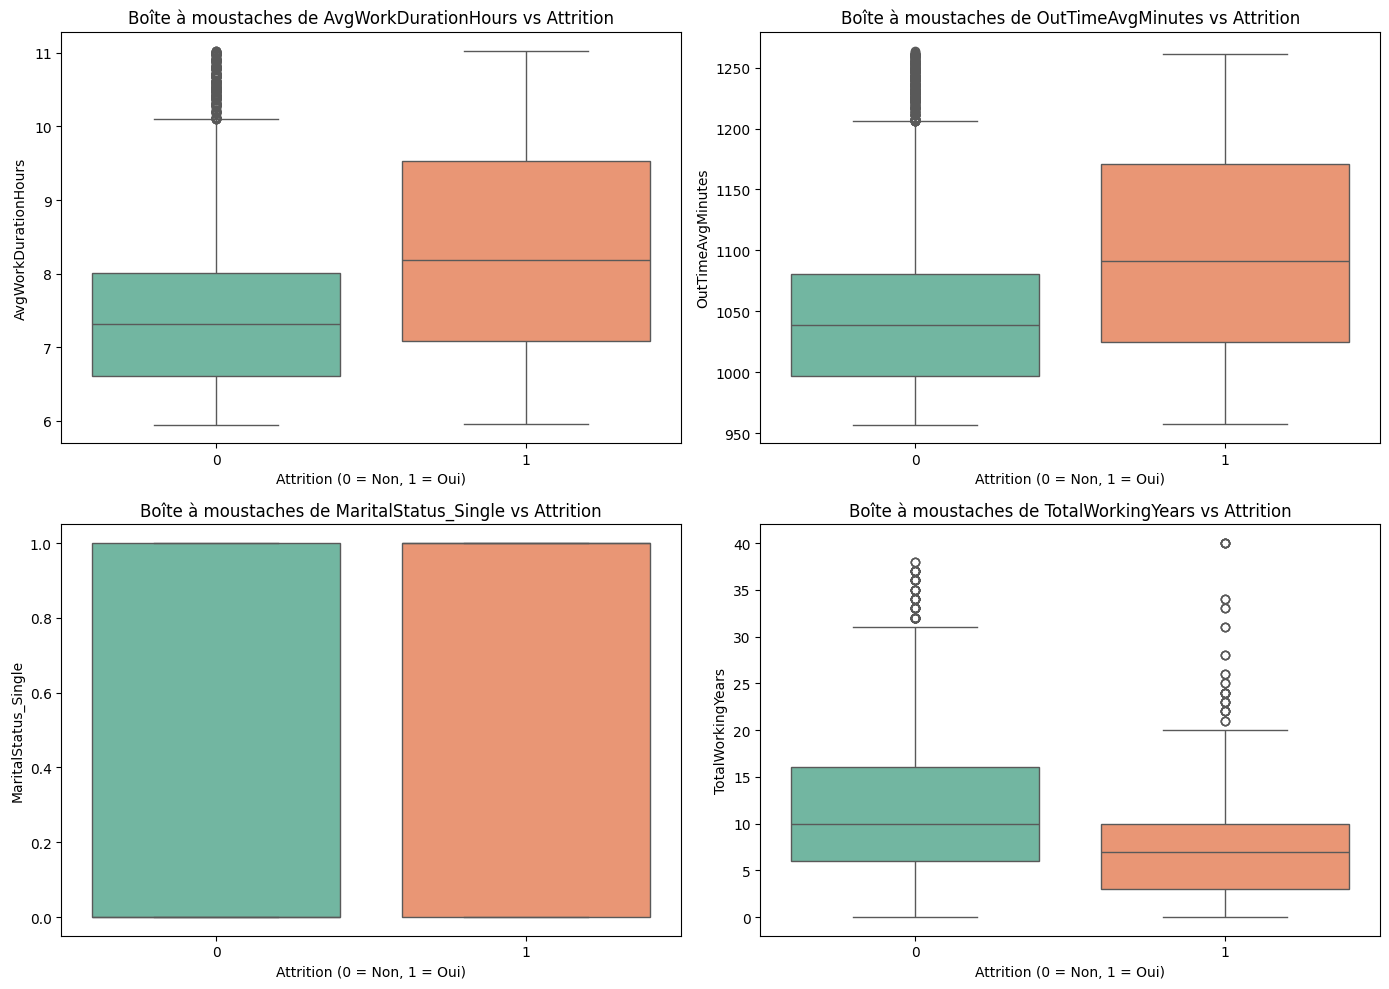

In [200]:
# Boxplots pour les 4 variables numériques les plus corrélées à l'Attrition
top_num_features = attrition_corr.abs().sort_values(ascending=False).head(4).index.tolist()

plt.figure(figsize=(14, 10))
for i, col in enumerate(top_num_features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='Attrition_num', y=col, hue='Attrition_num', data=corr_data, palette='Set2', legend=False)
    plt.title(f'Boîte à moustaches de {col} vs Attrition')
    plt.xlabel('Attrition (0 = Non, 1 = Oui)')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

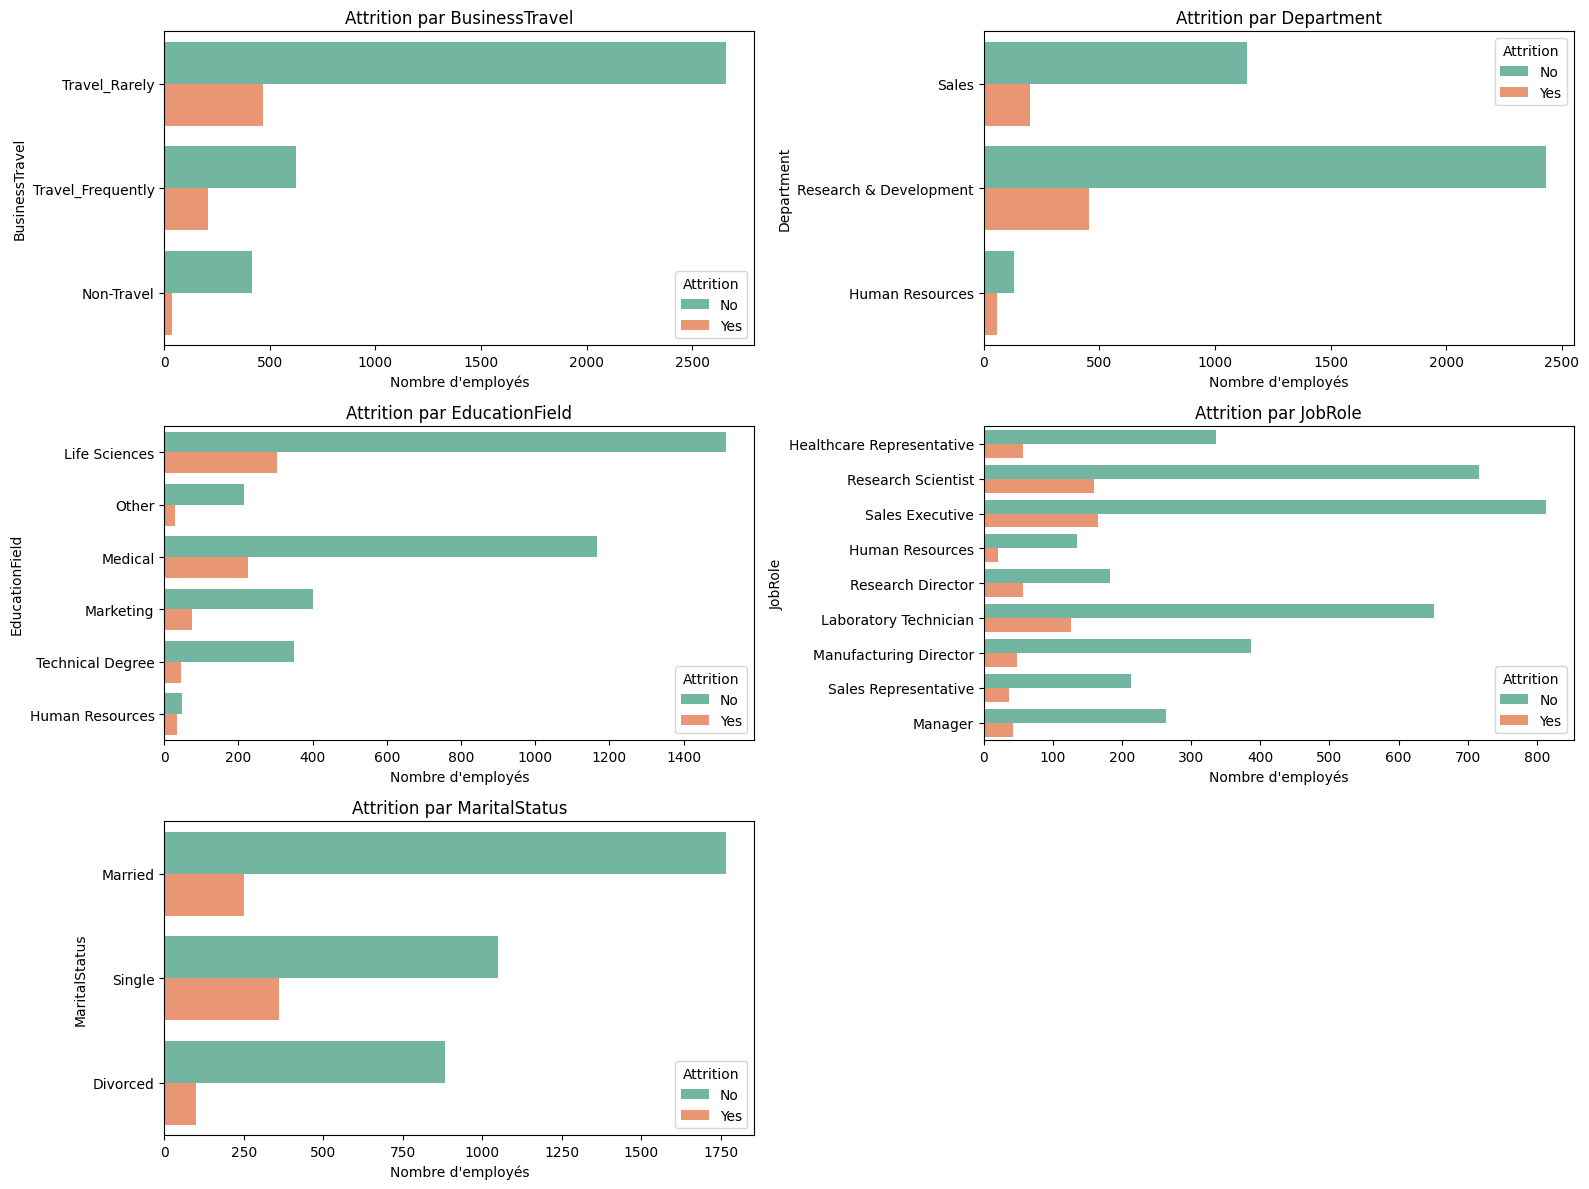

In [201]:
# Taux d'attrition sur les variables catégorielles (Barplots croisés)
plt.figure(figsize=(16, 12))
# features_to_encode contient ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']
for i, col in enumerate(features_to_encode, 1):
    plt.subplot(3, 2, i)
    sns.countplot(y=col, hue='Attrition', data=df_general, palette='Set2')
    plt.title(f'Attrition par {col}')
    plt.xlabel("Nombre d'employés")
    plt.ylabel(col)
plt.tight_layout()
plt.show()

## Courbes de Régression Logistique

Meilleures caractéristiques utilisées pour la régression logistique: ['AvgWorkDurationHours', 'OutTimeAvgMinutes']


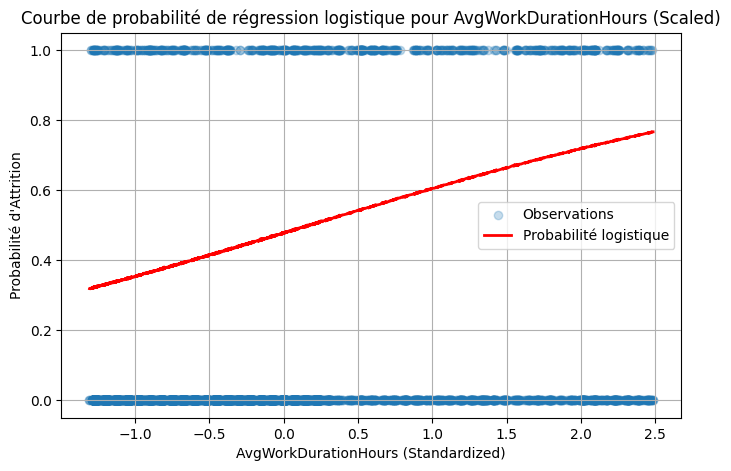

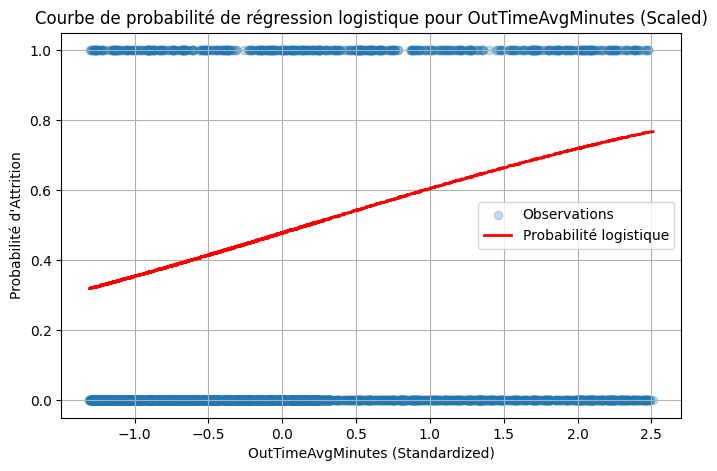

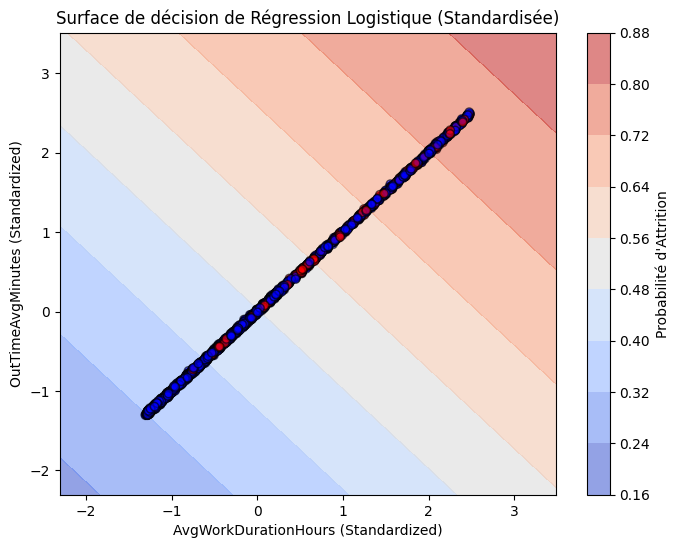

In [202]:
# Entraîner un modèle de régression logistique sur les deux caractéristiques les plus corrélées
top_features = attrition_corr.abs().sort_values(ascending=False).head(2).index.tolist()
print('Meilleures caractéristiques utilisées pour la régression logistique:', top_features)

X_log = corr_data[top_features]
y_log = corr_data['Attrition_num']

scaler_log = StandardScaler()
X_log_scaled = pd.DataFrame(scaler_log.fit_transform(X_log), columns=X_log.columns, index=X_log.index)

clf_log = LogisticRegression(max_iter=500, class_weight='balanced')
clf_log.fit(X_log_scaled, y_log)

# Tracer la courbe de probabilité pour chaque caractéristique principale séparément
for feature in top_features:
    plt.figure(figsize=(8, 5))
    idx = X_log_scaled[feature].sort_values().index
    values = X_log_scaled.loc[idx, feature].values
    probs = clf_log.predict_proba(X_log_scaled.loc[idx])[:, 1]
    plt.scatter(X_log_scaled[feature], y_log, alpha=0.25, label='Observations')
    plt.plot(values, probs, color='red', linewidth=2, label='Probabilité logistique')
    plt.title(f'Courbe de probabilité de régression logistique pour {feature} (Scaled)')
    plt.xlabel(f'{feature} (Standardized)')
    plt.ylabel('Probabilité d\'Attrition')
    plt.legend()
    plt.grid(True)
    plt.show()

# Si les deux caractéristiques sont numériques, afficher la limite de décision en 2D
if len(top_features) == 2:
    feature_x, feature_y = top_features
    x_min, x_max = X_log_scaled[feature_x].min() - 1, X_log_scaled[feature_x].max() + 1
    y_min, y_max = X_log_scaled[feature_y].min() - 1, X_log_scaled[feature_y].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_df = pd.DataFrame(grid, columns=[feature_x, feature_y])
    probs_grid = clf_log.predict_proba(grid_df)[:, 1].reshape(xx.shape)
    plt.figure(figsize=(8, 6))
    contour = plt.contourf(xx, yy, probs_grid, cmap='coolwarm', alpha=0.6)
    plt.scatter(X_log_scaled[feature_x], X_log_scaled[feature_y], c=y_log, cmap='bwr', edgecolor='k', alpha=0.6)
    plt.colorbar(contour, label='Probabilité d\'Attrition')
    plt.title('Surface de décision de Régression Logistique (Standardisée)')
    plt.xlabel(f'{feature_x} (Standardized)')
    plt.ylabel(f'{feature_y} (Standardized)')
    plt.show()

# Préparation du Dataset

In [203]:
train_set = encoded.join(df_general[numeric_features])

# Division du Dataset

In [204]:
train_X, test_X,train_Y, test_Y = train_test_split(train_set, multi_y, test_size=0.2, random_state=1337, stratify=multi_y)

## Création d'un set de validation

In [205]:
multi_train_X, multi_val_X, multi_train_Y, multi_val_Y = train_test_split(train_X, train_Y, test_size=0.3, random_state=1337, stratify=train_Y)

scaler = StandardScaler()
multi_train_X_scaled = pd.DataFrame(scaler.fit_transform(multi_train_X), columns=multi_train_X.columns, index=multi_train_X.index)
multi_val_X_scaled = pd.DataFrame(scaler.transform(multi_val_X), columns=multi_val_X.columns, index=multi_val_X.index)
test_X_scaled = pd.DataFrame(scaler.transform(test_X), columns=test_X.columns, index=test_X.index)

## Modélisation et évaluation comparative

In [206]:
# Calculer scale_pos_weight pour XGBoost pour gérer le déséquilibre des classes
scale_pos_weight = float(np.sum(multi_train_Y == 0)) / np.sum(multi_train_Y == 1)

# Comparer plusieurs classifieurs pour sélectionner le meilleur modèle
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        C=0.5
        ),
    'Random Forest': RandomForestClassifier(
        random_state=1337,
        class_weight='balanced',
        n_estimators=300,
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        random_state=1337,
        max_depth=5,
        learning_rate=0.05,
        n_estimators=300,
        subsample=0.8,
    ),
    'XGBoost': XGBClassifier(
        eval_metric='logloss',
        random_state=1337,
        scale_pos_weight=scale_pos_weight,
        max_depth=5,          # remonté de 3 à 5 (comme le GB optimal)
        min_child_weight=3,   # baissé de 5 à 3 (moins restrictif)
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,        # baissé de 1.0 (trop régularisé)
        reg_lambda=3.0,       # baissé de 8.0 (trop régularisé)
        n_estimators=300,
        learning_rate=0.05,
        )
}


results = []
for name, model in models.items():
    # Score F1 de validation croisée sur l'ensemble d'entraînement (utiliser Pipeline pour éviter les fuites de données)
    pipeline = Pipeline([('scaler', StandardScaler()), ('classifier', model)])
    cv_scores = cross_val_score(pipeline, multi_train_X, multi_train_Y, cv=5, scoring='f1_weighted')
    
    # Entraîner sur l'ensemble d'entraînement en utilisant les caractéristiques standardisées
    model.fit(multi_train_X_scaled, multi_train_Y)
    
    # Prédire sur l'ensemble de validation en utilisant les caractéristiques standardisées
    proba = model.predict_proba(multi_val_X_scaled)[:, 1]
    # Optimiser le seuil sur la validation pour chaque modèle
    best_threshold = 0.5
    best_f1_leaver = 0

    for t in np.arange(0.20, 0.60, 0.01):
        preds_t = (proba >= t).astype(int)
        f1_leaver = f1_score(multi_val_Y, preds_t, pos_label=1)
        if f1_leaver > best_f1_leaver:
            best_f1_leaver = f1_leaver
            best_threshold = t

    preds = (proba >= best_threshold).astype(int)
    
    results.append({
        'Model': name,
        'Seuil': best_threshold,
        'CV F1 Mean': cv_scores.mean(),
        'CV F1 Std': cv_scores.std(),
        'Val F1 Leaver': best_f1_leaver,
        'Val Accuracy': accuracy_score(multi_val_Y, preds),
        'Val Precision': precision_score(multi_val_Y, preds, average='weighted', zero_division=0),
        'Val Recall': recall_score(multi_val_Y, preds, average='weighted', zero_division=0),
        'Val F1': f1_score(multi_val_Y, preds, average='weighted', zero_division=0)
    })

results_df = pd.DataFrame(results).sort_values(by='Val F1 Leaver', ascending=False)
print(results_df)

best_model_name = results_df.iloc[0]['Model']
print(f"\nMeilleur modèle par F1 score : {best_model_name}")

# Conserver le meilleur modèle pour une évaluation ultérieure
best_model = models[best_model_name]

# Récupérer le seuil optimal pour le meilleur modèle
best_threshold = results_df.loc[results_df['Model'] == best_model_name, 'Seuil'].values[0]


                 Model  Seuil  CV F1 Mean  CV F1 Std  Val F1 Leaver  \
1        Random Forest   0.30    0.880281   0.014371       0.890855   
2    Gradient Boosting   0.20    0.921429   0.010743       0.881159   
3              XGBoost   0.58    0.931371   0.013660       0.866667   
0  Logistic Regression   0.59    0.759047   0.017864       0.505695   

   Val Accuracy  Val Precision  Val Recall    Val F1  
1      0.965061       0.964838    0.965061  0.964936  
2      0.961284       0.961582    0.961284  0.961420  
3      0.958451       0.957664    0.958451  0.957835  
0      0.795090       0.841801    0.795090  0.811809  

Meilleur modèle par F1 score : Random Forest


Évaluation sur le Set de Validation :
Exactitude (Accuracy) : 0.9651
Précision : 0.9648
Rappel (Recall) : 0.9651
F1-Score: 0.9649


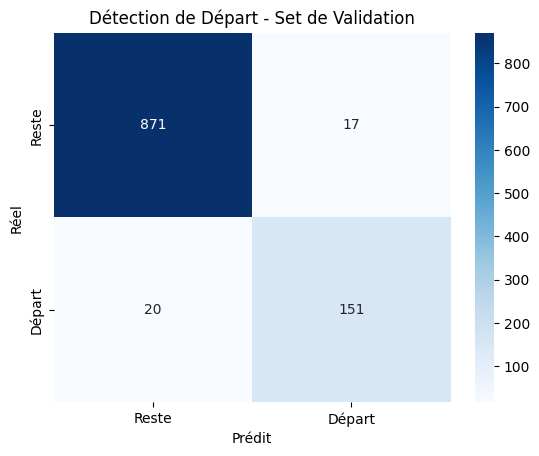

Rapport de Classification pour le Set de Validation :
              precision    recall  f1-score   support

       Reste       0.98      0.98      0.98       888
      Départ       0.90      0.88      0.89       171

    accuracy                           0.97      1059
   macro avg       0.94      0.93      0.94      1059
weighted avg       0.96      0.97      0.96      1059



In [207]:
# Prédire et évaluer le modèle sur l'ensemble de validation
multi_predictions = best_model.predict_proba(multi_val_X_scaled)[:, 1]
preds = (multi_predictions >= best_threshold).astype(int)
accuracy = accuracy_score(multi_val_Y, preds)
precision = precision_score(multi_val_Y, preds, average='weighted', zero_division=0)
recall = recall_score(multi_val_Y, preds, average='weighted', zero_division=0)
f1 = f1_score(multi_val_Y, preds, average='weighted', zero_division=0)
print(f"Évaluation sur le Set de Validation :")
print(f"Exactitude (Accuracy) : {accuracy:.4f}")
print(f"Précision : {precision:.4f}")
print(f"Rappel (Recall) : {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Matrice de Confusion pour l'ensemble de validation
conf_matrix = confusion_matrix(multi_val_Y, preds)
# 0 -> Reste (Non), 1 -> Départ (Oui)
class_labels = ['Reste', 'Départ']
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title(f'Détection de Départ - Set de Validation')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.show()

# Rapport de Classification pour l'ensemble de validation
print("Rapport de Classification pour le Set de Validation :")
print(classification_report(multi_val_Y, preds, target_names=class_labels, zero_division=0))


Évaluation sur le Set de Test :
Seuil utilisé : 0.30
Exactitude (Accuracy) : 0.9898
Précision : 0.9898
Rappel (Recall) : 0.9898
F1-Score: 0.9897


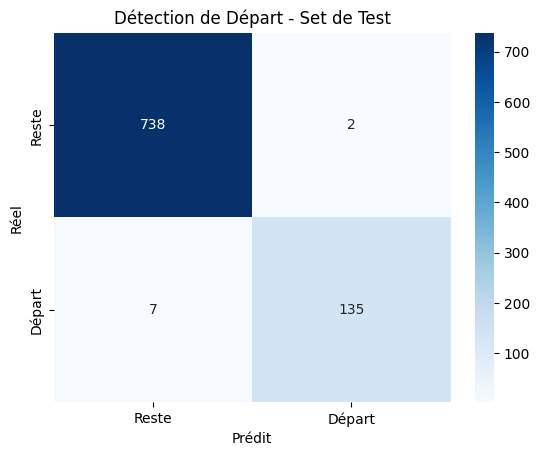

Rapport de Classification pour le Set de Test :
              precision    recall  f1-score   support

       Reste       0.99      1.00      0.99       740
      Départ       0.99      0.95      0.97       142

    accuracy                           0.99       882
   macro avg       0.99      0.97      0.98       882
weighted avg       0.99      0.99      0.99       882



In [208]:
# Évaluation finale sur l'ensemble de test
# 1. Réentraîner le normaliseur et le modèle sur l'ensemble d'entraînement complet 80% (Train + Validation)
final_scaler = StandardScaler()
full_train_X_scaled = pd.DataFrame(final_scaler.fit_transform(train_X), columns=train_X.columns, index=train_X.index)
test_X_scaled = pd.DataFrame(final_scaler.transform(test_X), columns=test_X.columns, index=test_X.index)

# IMPORTANT : réentraîner le modèle sur le train complet (80%) avec le nouveau scaler
best_model.fit(full_train_X_scaled, train_Y)

# Prédire avec le seuil optimisé (et non .predict() qui utilise 0.5)
test_proba = best_model.predict_proba(test_X_scaled)[:, 1]
test_multi_predictions = (test_proba >= best_threshold).astype(int)

test_accuracy = accuracy_score(test_Y, test_multi_predictions)
test_precision = precision_score(test_Y, test_multi_predictions, average='weighted', zero_division=0)
test_recall = recall_score(test_Y, test_multi_predictions, average='weighted', zero_division=0)
test_f1 = f1_score(test_Y, test_multi_predictions, average='weighted', zero_division=0)
print(f"\nÉvaluation sur le Set de Test :")
print(f"Seuil utilisé : {best_threshold:.2f}")
print(f"Exactitude (Accuracy) : {test_accuracy:.4f}")
print(f"Précision : {test_precision:.4f}")
print(f"Rappel (Recall) : {test_recall:.4f}")
print(f"F1-Score: {test_f1:.4f}")

# Matrice de Confusion pour l'ensemble de test
test_conf_matrix = confusion_matrix(test_Y, test_multi_predictions)
sns.heatmap(test_conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title(f'Détection de Départ - Set de Test')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.show()

# Rapport de Classification pour l'ensemble de test
print("Rapport de Classification pour le Set de Test :")
print(classification_report(test_Y, test_multi_predictions, target_names=class_labels, zero_division=0))

## Courbe ROC & AUC

Score ROC AUC: 0.9929


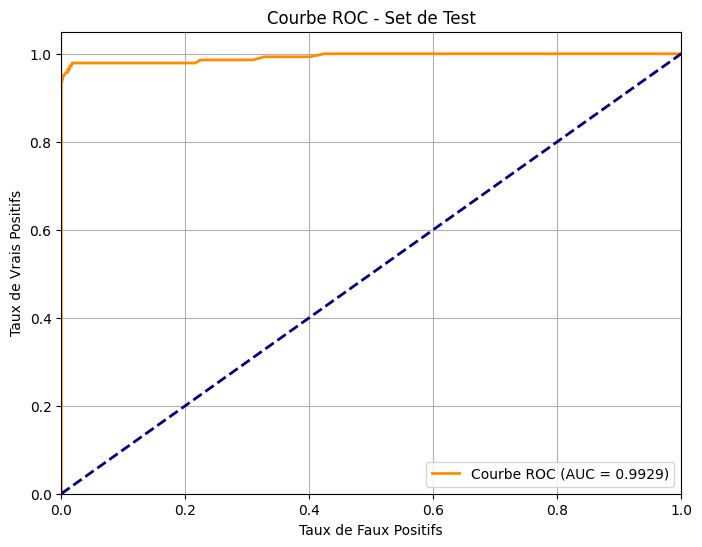

In [209]:
# Calculer les probabilités pour la classe positive
test_proba = best_model.predict_proba(test_X_scaled)[:, 1]

# Calculer l'AUC (Surface sous la courbe ROC)
roc_auc = roc_auc_score(test_Y, test_proba)
print(f"Score ROC AUC: {roc_auc:.4f}")

# Calculer les métriques de la courbe ROC
fpr, tpr, thresholds = roc_curve(test_Y, test_proba)

# Tracer la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs')
plt.title('Courbe ROC - Set de Test')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

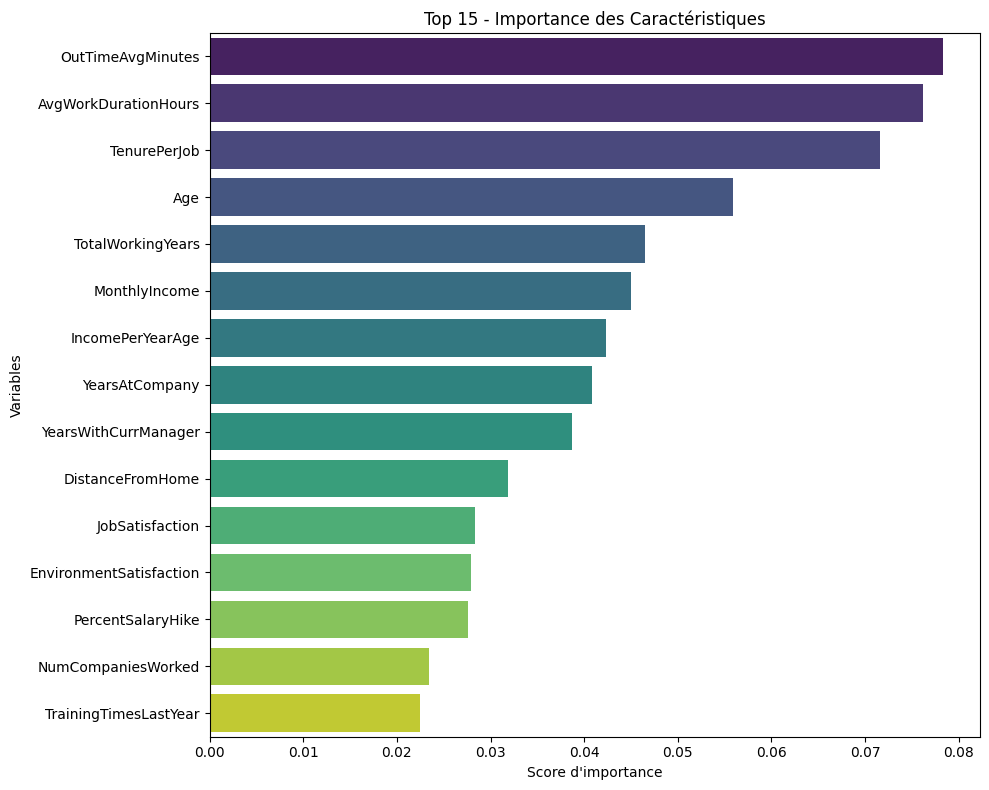

In [210]:
# Importance des Caractéristiques du Meilleur Modèle (XGBoost)
importances = best_model.feature_importances_
feature_names = multi_train_X_scaled.columns

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=feat_imp_df.head(15), palette='viridis', legend=False)
plt.title('Top 15 - Importance des Caractéristiques')
plt.xlabel("Score d'importance")
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

DIAGNOSTIC DE SURAPPRENTISSAGE

Modèle : Random Forest | Seuil : 0.30

Set              Accuracy   F1 Leaver   Recall Leaver   Prec Leaver
-----------------------------------------------------------------
Train              1.0000      1.0000          1.0000        1.0000
Test               0.9898      0.9677          0.9507        0.9854

--- Écart Train → Test ---
Gap F1 Leaver :     +0.0323
Gap Recall Leaver : +0.0493
✅ Pas de surapprentissage significatif (gap < 0.05)

Génération des courbes d'apprentissage...


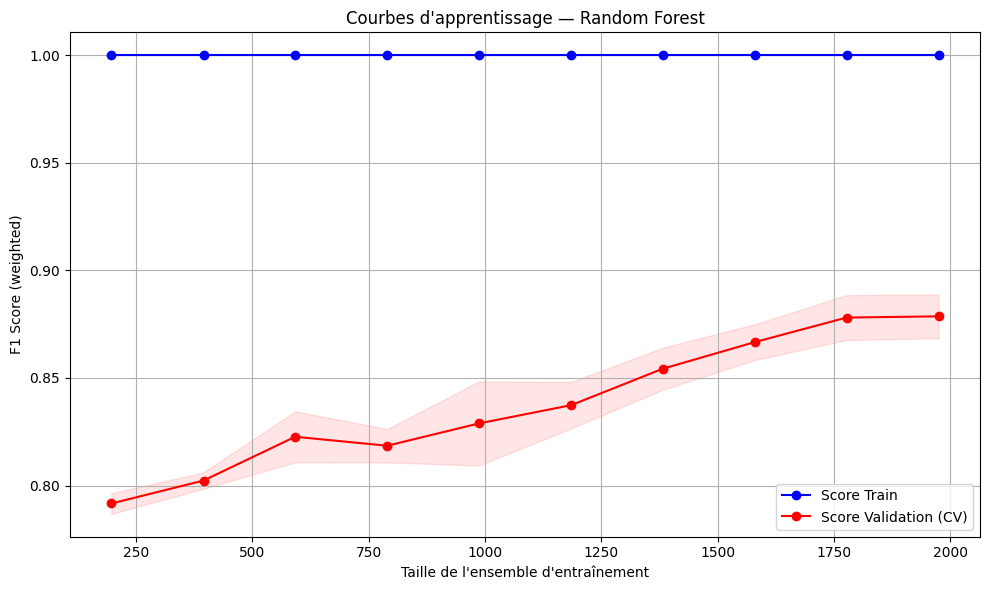


Interprétation :
  Écart final learning curves (train - val) : 0.1213
  ✅ Le gap train→test réel (0.0323) confirme : pas de surapprentissage
  ℹ️  Le gap des learning curves est élevé car le Random Forest
     score toujours ~100% sur le train — c'est normal et attendu.


In [211]:
# ============================================================
# Diagnostic de surapprentissage
# ============================================================

print("=" * 60)
print("DIAGNOSTIC DE SURAPPRENTISSAGE")
print("=" * 60)

# 1. Scores Train vs Validation vs Test pour le meilleur modèle
sets = {
    'Train':  (full_train_X_scaled, train_Y),
    'Test':   (test_X_scaled,       test_Y),
}

print(f"\nModèle : {best_model_name} | Seuil : {best_threshold:.2f}\n")
print(f"{'Set':<14} {'Accuracy':>10} {'F1 Leaver':>11} {'Recall Leaver':>15} {'Prec Leaver':>13}")
print("-" * 65)

overfit_data = {}
for set_name, (X, y) in sets.items():
    proba = best_model.predict_proba(X)[:, 1]
    preds = (proba >= best_threshold).astype(int)
    overfit_data[set_name] = {
        'Accuracy':       accuracy_score(y, preds),
        'F1 Leaver':      f1_score(y, preds, pos_label=1),
        'Recall Leaver':  recall_score(y, preds, pos_label=1),
        'Precision Leaver': precision_score(y, preds, pos_label=1, zero_division=0),
    }
    d = overfit_data[set_name]
    print(f"{set_name:<14} {d['Accuracy']:>10.4f} {d['F1 Leaver']:>11.4f} "
          f"{d['Recall Leaver']:>15.4f} {d['Precision Leaver']:>13.4f}")

# 2. Calcul de l'écart (gap) Train - Test
gap_f1 = overfit_data['Train']['F1 Leaver'] - overfit_data['Test']['F1 Leaver']
gap_recall = overfit_data['Train']['Recall Leaver'] - overfit_data['Test']['Recall Leaver']

print(f"\n--- Écart Train → Test ---")
print(f"Gap F1 Leaver :     {gap_f1:+.4f}")
print(f"Gap Recall Leaver : {gap_recall:+.4f}")

if gap_f1 < 0.05:
    print("✅ Pas de surapprentissage significatif (gap < 0.05)")
elif gap_f1 < 0.10:
    print("⚠️  Surapprentissage léger (0.05 ≤ gap < 0.10) — à surveiller")
else:
    print("🔴 Surapprentissage détecté (gap ≥ 0.10) — le modèle mémorise le train")

# 3. Courbes d'apprentissage (learning curves)
from sklearn.model_selection import learning_curve

print("\nGénération des courbes d'apprentissage...")
train_sizes, train_scores, val_scores = learning_curve(
    best_model, 
    multi_train_X_scaled, multi_train_Y,
    cv=5, 
    scoring='f1_weighted',
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=1337
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='blue', label='Score Train')
plt.fill_between(train_sizes, 
                 train_scores.mean(axis=1) - train_scores.std(axis=1),
                 train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.1, color='blue')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', color='red', label='Score Validation (CV)')
plt.fill_between(train_sizes, 
                 val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.1, color='red')
plt.xlabel("Taille de l'ensemble d'entraînement")
plt.ylabel('F1 Score (weighted)')
plt.title(f'Courbes d\'apprentissage — {best_model_name}')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# Remplacer l'interprétation des learning curves par :
print("\nInterprétation :")
final_gap = train_scores.mean(axis=1)[-1] - val_scores.mean(axis=1)[-1]
print(f"  Écart final learning curves (train - val) : {final_gap:.4f}")
if gap_f1 < 0.05:
    print(f"  ✅ Le gap train→test réel ({gap_f1:.4f}) confirme : pas de surapprentissage")
    print(f"  ℹ️  Le gap des learning curves est élevé car le Random Forest")
    print(f"     score toujours ~100% sur le train — c'est normal et attendu.")
elif gap_f1 < 0.10:
    print(f"  ⚠️  Surapprentissage léger (gap réel = {gap_f1:.4f})")
else:
    print(f"  🔴 Surapprentissage détecté (gap réel = {gap_f1:.4f})")
    print("  💡 Solutions : réduire max_depth, augmenter min_child_weight,")
    print("     ajouter reg_alpha/reg_lambda, ou réduire le nombre de features")